In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error

In [8]:
df = pd.read_csv('/content/milk_production.csv')
print(df.columns)

Index(['month', 'production'], dtype='object')


In [9]:
df = pd.read_csv('/content/milk_production.csv')

# Convert to datetime
df['month'] = pd.to_datetime(df['month'])

# Set index
df.set_index('month', inplace=True)

df.head()

,production
month,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


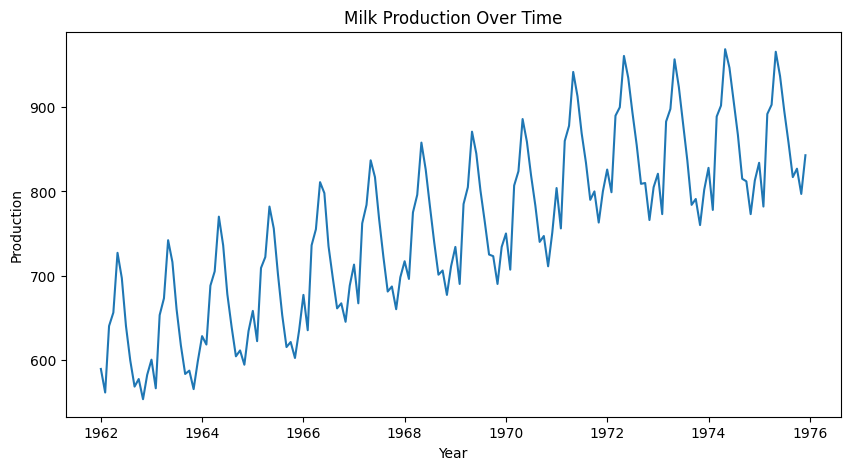

In [10]:
plt.figure(figsize=(10,5))
plt.plot(df['production'])
plt.title("Milk Production Over Time")
plt.xlabel("Year")
plt.ylabel("Production")
plt.show()

In [11]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['production'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.3038115874221308
p-value: 0.6274267086030311


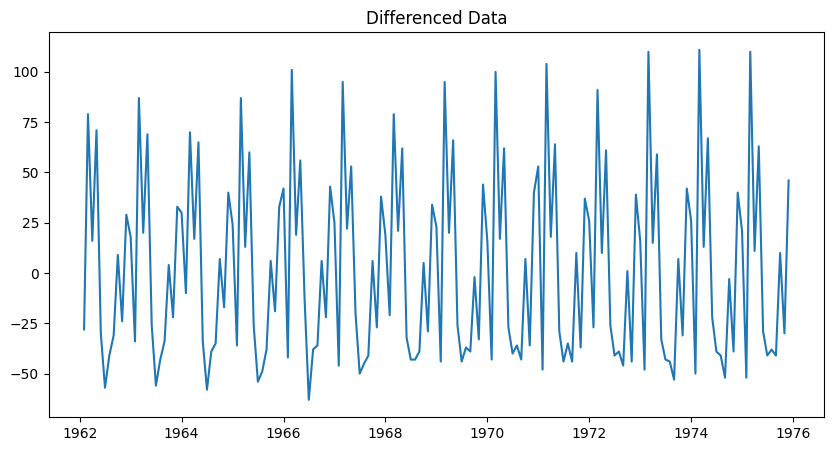

In [12]:
df_diff = df['production'].diff().dropna()

plt.figure(figsize=(10,5))
plt.plot(df_diff)
plt.title("Differenced Data")
plt.show()

In [13]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(df['production'],
                order=(1,1,1),
                seasonal_order=(1,1,1,12))

model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                         production   No. Observations:                  168
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -529.887
Date:                            Tue, 31 Mar 2026   AIC                           1069.775
Time:                                    16:34:56   BIC                           1084.992
Sample:                                01-01-1962   HQIC                          1075.956
                                     - 12-01-1975                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1395      0.337     -0.413      0.679      -0.801       0.522
ma.L1         -0.0942      0.335   

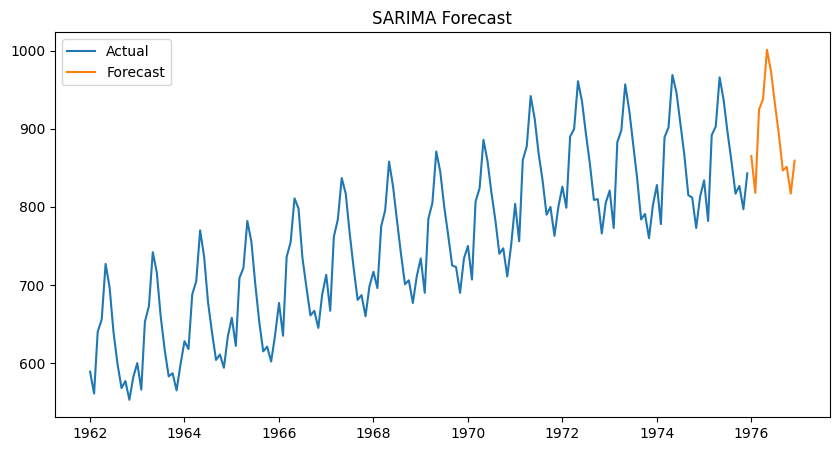

In [14]:
forecast = model_fit.forecast(steps=12)

plt.figure(figsize=(10,5))
plt.plot(df['production'], label='Actual')
plt.plot(forecast, label='Forecast')
plt.legend()
plt.title("SARIMA Forecast")
plt.show()

In [15]:
from sklearn.metrics import mean_squared_error

pred = model_fit.predict(start=0, end=len(df)-1)

mse = mean_squared_error(df['production'], pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 2692.5791849333505
